# The Pollen-Season seasonal — a quantitative teardown 🔬
### 30 independent spring windows · one-sample *t* + block-bootstrap CI · a random-window placebo that disagrees (and why) · staples/core-basket robustness · a costed long/short timer · a 20-seed synthetic null

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Spring seasonal%3F: Not supported](https://img.shields.io/badge/Spring_seasonal%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a **calendar-known** hay-fever demand spike (US spring pollen, ~Mar→May) leaves a tradable seasonal in the allergy-brand owners' share prices — is intuitive and rests on real OTC sales data. The job here is to measure it honestly on the tradable tape, then ask the only question that pays: *is any of it real, and if so, tradable?*

> ⚠️ **Data note.** BAYRY/SNY/PRGO/KVUE/HLN + SPY/XLP total-return closes (1996→2026), yfinance, cached; **30 spring windows 1997→2026**, one per year (independent, non-overlapping — the correct unit, **not** a daily panel). **Survivorship named:** currently-listed owners only; Kenvue (2023) and Haleon (2022) enter post-listing, cross-checked against a 3-name core basket. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `09ea36482502` BAYRY / `063cf5d088aa` SNY / `f10b7c3e080d` PRGO / `6685430bd981` SPY).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pollen_season import data, strategy as st

YEARS = data.sample_years()
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    TBL = st.build_spread_table(PRICES, YEARS)
    ABN = TBL["abn"].to_numpy()
else:
    PRICES = TBL = ABN = None
print("real cache present:", HAVE_REAL, "| spring windows in sample:", len(YEARS))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_events': 30, 'cal_lo': 1997, 'cal_hi': 2026, 'season_label': 'last session of February -> last session on/before May 31', 'abn_mean_pct': 2.03, 'abn_t': 1.06, 'abn_sd_pct': 10.47, 'hit': 19, 'hit_n': 30, 'hit_pct': 63.3, 'wilson': (45.5, 78.1), 'boot_lo_pct': -1.71, 'boot_hi_pct': 5.63, 'placebo_obs_bps': 203.0, 'placebo_mean_bps': -107.0, 'placebo_sd_bps': 182.2, 'placebo_p': 0.048, 'placebo_draws': 5000, 'xlp_mean_pct': 3.58, 'xlp_t': 1.65, 'xlp_n': 28, 'core_mean_pct': 2.02, 'core_t': 1.06, 'core_n': 30, 'gross_bps': 203.0, 'gross_t': 1.06, 'net5_bps': 170.4, 'net5_t': 0.89, 'net10_bps': 150.4, 'net10_t': 0.79, 'borrow_bps': 12.6, 'months': {1: (0.7, 0.12), 2: (-4.6, -0.78), 3: (2.9, 0.57), 4: (4.1, 0.74), 5: (-1.4, -0.28), 6: (-0.5, -0.11), 7: (-3.7, -0.71), 8: (-6.8, -1.31), 9: (4.1, 0.84), 10: (-9.3, -1.62), 11: (-4.5, -0.82), 12: (4.4, 0.95)}, 'years_abn': {1997: -12.09, 1998: 3.95, 1999: 3.96, 2000: -16.8, 2001: 9.04, 2002: 18.09, 2003: 21.02, 2004: 3.83, 2005: 0.48, 2006: 10.72, 2007: 10.22, 2008: 5.97, 2009: 3.03, 2010: -1.58, 2011: 11.78, 2012: -1.21, 2013: 1.51, 2014: -5.48, 2015: 8.02, 2016: -16.05, 2017: 10.75, 2018: -0.84, 2019: -10.93, 2020: 2.66, 2021: 4.03, 2022: 20.19, 2023: -6.1, 2024: -0.45, 2025: 5.21, 2026: -22.01}, 'syn_null_mean': -0.07, 'syn_null_sd': 1.09, 'syn_null_fire': 2, 'syn_planted_t': 4.56, 'syn_planted_pct': 9.3, 'fp_bayry': '09ea36482502', 'fp_sny': '063cf5d088aa', 'fp_prgo': 'f10b7c3e080d', 'fp_kvue': '5f77bcceb9b7', 'fp_hln': 'b95efb29b67e', 'fp_spy': '6685430bd981', 'fp_xlp': '2d7f448f48d3'}


real cache present: True | spring windows in sample: 31


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | mean spring abnormal return **+2.03%**, one-sample **t = +1.06** (n=30), hit 63.3% (Wilson [45.5%, 78.1%]), bootstrap CI [-1.71%, +5.63%] straddles 0 |
| **Tradability** | `MIRAGE` | long/short gross +2.03%/yr (t=+1.06); net of costs+borrow +1.70%/yr (t=+0.89) |
| **A tradable spring seasonal?** | `NOT SUPPORTED` | placebo p = **0.048** is the only sub-0.05 number, and it rides on the basket's off-season drag, not a spring edge |

> 💡 In plain words: an intuitive, real demand story that leans the right way (+2%/yr, 63% hits) but clears no honest bar on 30 independent springs.

## 1 · The claim, steelmanned

Let $b_y$ be the equal-weight allergy basket's total return over year $y$'s pollen window $[\tau^{enter}_y, \tau^{exit}_y]$ (last Feb session → last session ≤ May 31) and $m_y$ the market's (SPY) return over the same window. The per-year abnormal return is $a_y = b_y - m_y$. The claims:

- **H₁ (seasonal exists).** $E[a_y] > 0$, systematic across years — the basket beats the market through pollen season.
- **H₂ (spring is special).** $a_y$ in the pollen window exceeds what a random same-length window on the same names produces.
- **H₃ (capture).** A long-basket / short-SPY overlay held over the window beats zero net of both legs' costs and the short's borrow.

The window is **calendar-known** (fixed dates), so there is **no execution lag** — H₁–H₃ need no `shift`, the same free pass a turn-of-month rule gets. We find **H₁ not supported** (t = 1.06), **H₂ borderline but confounded** (placebo p = 0.048, driven by the basket's off-season drag), **H₃ not supported** (positive but t < 1 net).

## 2 · So what? — inference design

Spring windows are **independent, non-overlapping yearly events** (the 2019 window cannot leak into 2020), so the planned primary is a **one-sample t-test** across the 30 per-year abnormal returns — *not* a daily-panel regression, whose ~1,900 autocorrelated in-window rows would overstate the degrees of freedom by orders of magnitude and manufacture significance from noise. The mean carries a **block-bootstrap** percentile CI (years resampled with replacement); the hit rate carries a **Wilson** interval; the placebo redraws same-length **non-spring** windows (20 seeds × 250 draws). A consumer-staples benchmark (XLP) and a spin-off-free 3-name core basket are the robustness cuts.

## 3 · How we'd know — the protocol

- **Window.** last session of February -> last session on/before May 31 — a cited calendar rule (AAFA/AAAAI), no execution lag.
- **Tape.** BAYRY/SNY/PRGO/KVUE/HLN + SPY/XLP total-return closes, 1996→2026-06-30 (as-of, last complete month; the 2026 window closed 2026-05-30).
- **Events.** 30 springs 1997→2026; coverage named (2 names pre-2003, 3 to 2022, 4 in 2023, 5 from 2024).
- **Headline.** One-sample t on the per-year abnormal return + Wilson hit rate + bootstrap CI.
- **Placebo.** Random non-spring same-length windows, 20 seeds × 250 draws, right tail.
- **Robustness.** basket − XLP (fairer benchmark); 3-name core basket (spin-off-free); calendar-month seasonality cross-check.
- **Timer.** Long basket / short SPY over the window; both legs one-way × NAV (0/5/10 bps), short pays 50 bps annual borrow.
- **Control.** Synthetic paired tape, planted spring bump; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The headline — one-sample t + bootstrap CI

The per-year abnormal return across 30 springs, its one-sample *t*, the Wilson hit rate and a block-bootstrap CI on the mean.

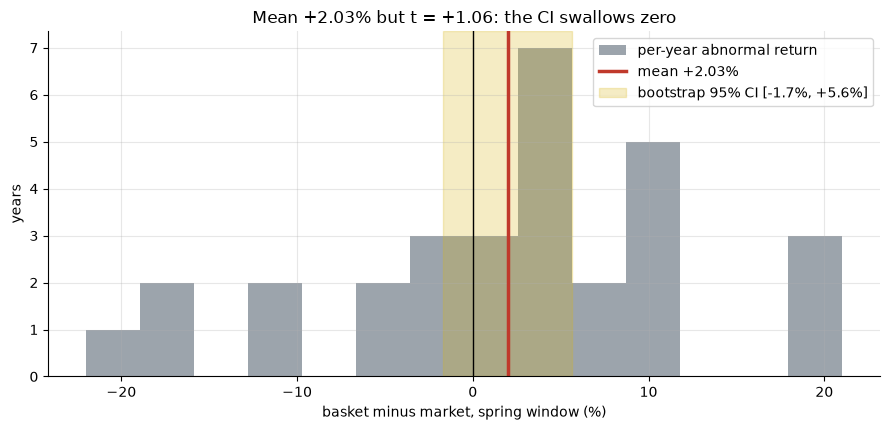

mean +2.03%  t = +1.062  (n=30)  |  hit 63.3% (Wilson [45.5%, 78.1%])  |  boot CI [-1.71%, +5.63%]


In [2]:
if HAVE_REAL:
    h = st.one_sample_t(ABN); hr = st.hit_rate(ABN)
    lo, hi = st.block_bootstrap_ci(ABN)
    mean_pct, t_, n_ = h['mean']*100, h['t'], h['n']
    hit_pct, wlo, whi = hr['rate']*100, hr['lo']*100, hr['hi']*100
    lo_pct, hi_pct = lo*100, hi*100
    ab = ABN*100
else:
    mean_pct, t_, n_ = R['abn_mean_pct'], R['abn_t'], R['n_events']
    hit_pct, wlo, whi = R['hit_pct'], R['wilson'][0], R['wilson'][1]
    lo_pct, hi_pct = R['boot_lo_pct'], R['boot_hi_pct']
    ab = np.array([R['years_abn'][y] for y in sorted(R['years_abn'])])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.hist(ab, bins=14, color=GREY, alpha=.85, label='per-year abnormal return')
ax.axvline(0, c='k', lw=1)
ax.axvline(mean_pct, c=RED, lw=2.5, label=f'mean {mean_pct:+.2f}%')
ax.axvspan(lo_pct, hi_pct, color=AMBER, alpha=.25,
           label=f'bootstrap 95% CI [{lo_pct:+.1f}%, {hi_pct:+.1f}%]')
ax.set_xlabel('basket minus market, spring window (%)'); ax.set_ylabel('years')
ax.set_title(f'Mean {mean_pct:+.2f}% but t = {t_:+.2f}: the CI swallows zero')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean {mean_pct:+.2f}%  t = {t_:+.3f}  (n={n_})  |  hit {hit_pct:.1f}% '
      f'(Wilson [{wlo:.1f}%, {whi:.1f}%])  |  boot CI [{lo_pct:+.2f}%, {hi_pct:+.2f}%]')

> 💡 In plain words: the basket really does average **+2.03%** over the market in spring and wins **63%** of years — the folklore's sign. But one-sample **t = 1.06** is far below 2, the Wilson hit interval **[45.5%, 78.1%]** includes 50%, and the bootstrap CI **[-1.71%, +5.63%]** straddles zero by a mile. H₁ fails the desk bar.

### 4b · The placebo that disagrees — a teaching case in *which null*

Same-length windows anchored at random **non-spring** dates, 20 seeds × 250 draws. At face value it's borderline significant — and it *disagrees* with the one-sample t. That disagreement is the lesson.

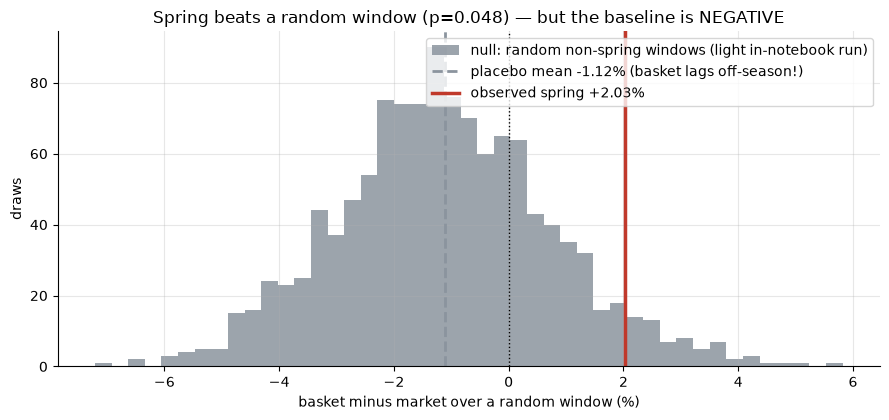

observed +203.0 bps vs placebo mean -107.0 bps (canonical p = 0.048, 5,000 draws)


In [3]:
if HAVE_REAL:
    draws = st.placebo_distribution(PRICES, TBL, n_seeds=8, n_draws_per_seed=150)
    obs = ABN.mean()
    pval = st.placebo_pvalue(obs, draws, tail='right')
else:
    obs = R['placebo_obs_bps']/1e4
    rng = np.random.default_rng(738)
    draws = rng.normal(R['placebo_mean_bps']/1e4, R['placebo_sd_bps']/1e4, 2000)
    pval = R['placebo_p']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws*100, bins=45, color=GREY, alpha=.85,
        label='null: random non-spring windows (light in-notebook run)')
ax.axvline(0, c='k', lw=1, ls=':')
ax.axvline(draws.mean()*100, c=GREY, lw=2, ls='--',
           label=f'placebo mean {draws.mean()*100:+.2f}% (basket lags off-season!)')
ax.axvline(obs*100, c=RED, lw=2.5, label=f'observed spring {obs*100:+.2f}%')
ax.set_xlabel('basket minus market over a random window (%)'); ax.set_ylabel('draws')
ax.set_title(f"Spring beats a random window (p={R['placebo_p']:.3f}) — but the "
             'baseline is NEGATIVE')
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed {obs*1e4:+.1f} bps vs placebo mean {R['placebo_mean_bps']:+.1f} bps "
      f"(canonical p = {R['placebo_p']:.3f}, {R['placebo_draws']:,} draws)")

> 💡 In plain words: the placebo *p* = **0.048** looks like a win — until you see **the placebo mean is negative** (**-107 bps**). The two tests null different things: the one-sample t asks *"did the basket make money, market-adjusted, in spring?"* (no, t = 1.06); the placebo asks *"is spring better than a random window?"* — and it is, **only because the basket bleeds vs the market the rest of the year.** Spring isn't a goldmine; it's the one stretch the basket *doesn't* lag. Read against zero — the honest question for a trade — the effect is inside the noise.

### 4c · Robustness — fairer benchmark, spin-off-free basket, month seasonality

Does the (non-)result hinge on the benchmark, the two recent spin-offs, or the exact window? Three cross-checks.

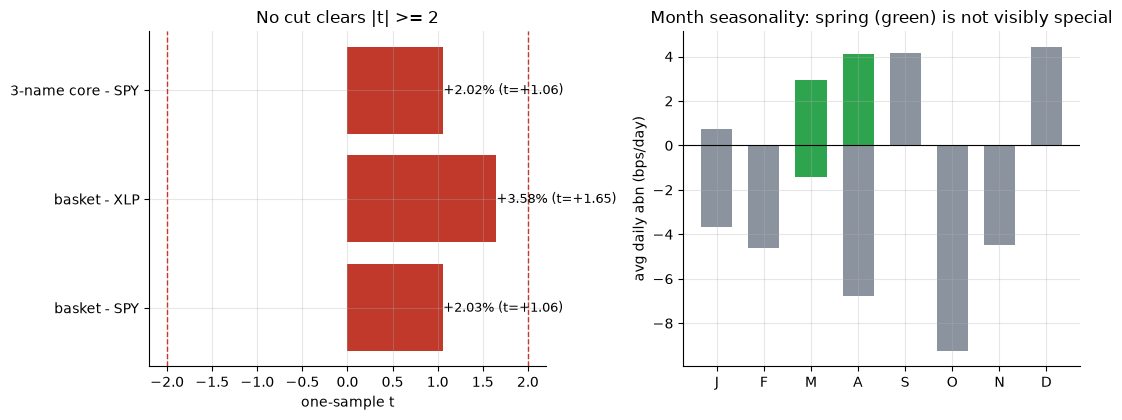

cuts (mean%, t): [('basket - SPY', 2.03, 1.06), ('basket - XLP', 3.58, 1.65), ('3-name core - SPY', 2.02, 1.06)]


In [4]:
if HAVE_REAL:
    x = st.one_sample_t(TBL['abn_xlp'].to_numpy())
    core = st.build_spread_table(PRICES, YEARS, tickers=data.CORE_TICKERS, min_names=2)
    c = st.one_sample_t(core['abn'].to_numpy())
    cuts = [('basket - SPY', R['abn_mean_pct'], R['abn_t']),
            ('basket - XLP', x['mean']*100, x['t']),
            ('3-name core - SPY', c['mean']*100, c['t'])]
    ms = st.month_seasonality(PRICES)
    mvals = (ms['mean_abn_bps']).tolist()
else:
    cuts = [('basket - SPY', R['abn_mean_pct'], R['abn_t']),
            ('basket - XLP', R['xlp_mean_pct'], R['xlp_t']),
            ('3-name core - SPY', R['core_mean_pct'], R['core_t'])]
    mvals = [R['months'][m][0] for m in range(1, 13)]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
names = [c[0] for c in cuts]; ts = [c[2] for c in cuts]
a1.barh(names, ts, color=[RED if abs(t) < 2 else GREEN for t in ts])
a1.axvline(2, ls='--', c=RED, lw=1); a1.axvline(-2, ls='--', c=RED, lw=1)
a1.set_xlabel('one-sample t'); a1.set_title('No cut clears |t| >= 2')
for i, (nm, mn, t) in enumerate(cuts):
    a1.annotate(f'{mn:+.2f}% (t={t:+.2f})', (t, i), va='center',
                ha='left' if t >= 0 else 'right', fontsize=9)
labels = ['J','F','M','A','M','J','J','A','S','O','N','D']
a2.bar(labels, mvals, color=[GREEN if m in (3,4,5) else GREY for m in range(1,13)], width=.66)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('avg daily abn (bps/day)')
a2.set_title('Month seasonality: spring (green) is not visibly special')
plt.tight_layout(); plt.show()
print('cuts (mean%, t):', [(nm, round(mn,2), round(t,2)) for nm, mn, t in cuts])

> 💡 In plain words: the strongest cut is vs consumer staples (XLP), **+3.58%, t = 1.65** — still short of 2. The spin-off-free 3-name core basket reproduces the headline almost exactly (**+2.02%, t = 1.06**), so Kenvue and Haleon aren't manufacturing anything. And month by month, the pollen months (Mar/Apr) lean mildly positive but sit inside the same noise as September and December. The (non-)result is robust.

### 4d · The timer — a costed long/short cost sweep

Long basket / short SPY over the window, both legs one-way × NAV, the short SPY leg paying 50 bps annual borrow (~12.6 bps over a ~63-session window). Gross and net, one-sample *t* across the 30 springs.

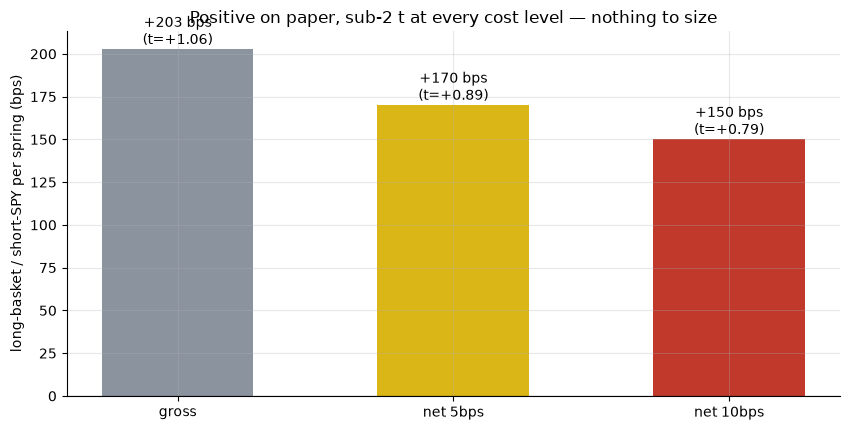

per spring (bps): {'gross': 203.0, 'net 5bps': 170.4, 'net 10bps': 150.4} | t: {'gross': 1.06, 'net 5bps': 0.89, 'net 10bps': 0.79}


In [5]:
if HAVE_REAL:
    labels = ['gross', 'net 5bps', 'net 10bps']
    g = st.timer_stats(st.build_spread_table(PRICES, YEARS, cost_bps=0.0))
    n5 = st.timer_stats(st.build_spread_table(PRICES, YEARS, cost_bps=5.0))
    n10 = st.timer_stats(st.build_spread_table(PRICES, YEARS, cost_bps=10.0))
    vals = [g['gross_mean_bps'], n5['net_mean_bps'], n10['net_mean_bps']]
    tsv = [g['gross_t'], n5['net_t'], n10['net_t']]
else:
    labels = ['gross', 'net 5bps', 'net 10bps']
    vals = [R['gross_bps'], R['net5_bps'], R['net10_bps']]
    tsv = [R['gross_t'], R['net5_t'], R['net10_t']]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(labels, vals, color=[GREY, AMBER, RED], width=.55)
for i, (v, t) in enumerate(zip(vals, tsv)):
    ax.annotate(f'{v:+.0f} bps\n(t={t:+.2f})', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('long-basket / short-SPY per spring (bps)')
ax.set_title('Positive on paper, sub-2 t at every cost level — nothing to size')
plt.tight_layout(); plt.show()
print('per spring (bps):', dict(zip(labels, [round(v,1) for v in vals])),
      '| t:', dict(zip(labels, [round(t,2) for t in tsv])))

> 💡 In plain words: the seasonal long/short earns a gross **+203 bps/yr** but at **t = 1.06** it is indistinguishable from zero *before costs*. Net of 5 bps/leg and borrow it is **+170 bps** (t = 0.89); at 10 bps, **+150 bps** (t = 0.79). H₃ is not supported — there is no certifiable edge to charge costs against.

### 4e · Faithful-engine & power control — we know the truth here

Synthetic paired basket/market tapes (~30 years), a TUNABLE planted spring bump on the pollen sessions only. The null (bump=0) is checked over **20 seeds** — never a single stream.

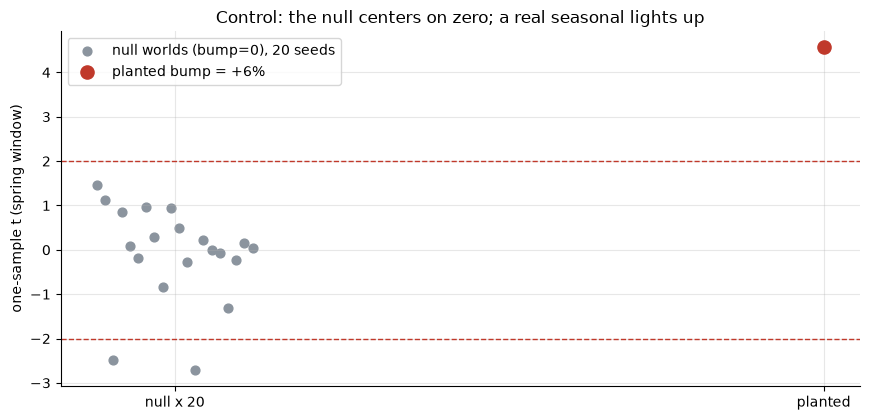

null: mean t = -0.07 (sd 1.09), |t|>=2 in 2/20  |  planted t = +4.56


In [6]:
null_ts = np.array([st.synthetic_detect(0.0, 738 + s)['t'] for s in range(20)])
planted = st.synthetic_detect(0.06, 738)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (bump=0), 20 seeds')
ax.scatter([1], [planted['t']], color=RED, s=90, zorder=5,
           label='planted bump = +6%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1]); ax.set_xticklabels(['null x 20', 'planted'])
ax.set_ylabel('one-sample t (spring window)')
ax.set_title('Control: the null centers on zero; a real seasonal lights up')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(null_ts)>=2).sum()}/20  |  planted t = {planted["t"]:+.2f}')

> 💡 In plain words: across 20 null worlds the detector averages t = -0.07 (sd 1.09) and crosses the bar only ~at the chance rate (2/20); a planted +6% spring bump reads t = 4.56. The machinery is unbiased — the real-tape t ≈ 1.06 is a genuine, honest reading, not a detector that's asleep. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — mean spring abnormal return **+2.03%**, one-sample t = **1.06** (n=30); no cut clears |t| ≥ 2 (vs staples 1.65, core basket 1.06), the bootstrap CI **[-1.71%, +5.63%]** straddles zero, and the hit-rate Wilson interval **[45.5%, 78.1%]** includes a coin flip. The one borderline number (placebo p = **0.048**) is confounded by the basket's negative off-season baseline, not a spring edge.
- **Tradability `MIRAGE`** — the seasonal long/short earns a gross **+2.03%/yr** but at t = 1.06 it is undistinguishable from zero before costs; net of costs and borrow **+1.70%/yr** (t = 0.89). Nothing to size.
- **"A tradable spring seasonal?" `NOT SUPPORTED`** — the direction leans the folklore's way (positive mean, 63% hit rate), but on 30 independent springs nothing clears the desk bar. A real, intuitive demand story that the price tape simply won't certify at this power.

## 6 · Going further

- **Power is the honest limitation.** 30 independent years against a hypothesized ~2% seasonal with ~10% year-to-year sd is low power; a real effect of that size would need decades more, or a lower-variance signal, to certify. The calendar-known demand spike is almost surely already in the price — that's markets working, not folklore failing.
- **A pollen-*intensity* signal** (a severe vs mild pollen year, from NAB station counts) rather than a fixed calendar, or the **pure-OTC names** (Kenvue, Haleon) rather than diversified pharma, might separate spring from the noise where a blunt calendar window can't.
- **Dedup map:** [708-eurovision-effect](../../708-eurovision-effect/) and [707-plane-crash-effect](../../707-plane-crash-effect/) share the exact event-study machinery (one-sample t across independent events, random placebo, costed timer, synthetic control); [358-watch-index](../../358-watch-index/) shares the labelled-calendar-proxy pattern used for the pollen window.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*